Available bands: ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
=== Average Cross-Validation Metrics ===
MSE: 0.0041
MAE: 0.0522
RMSE: 0.0638
R2: 0.1488


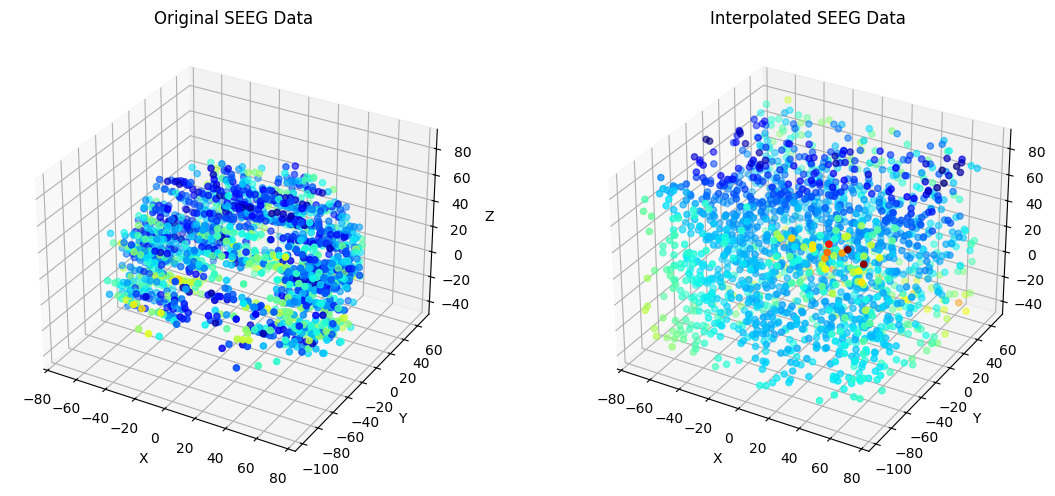

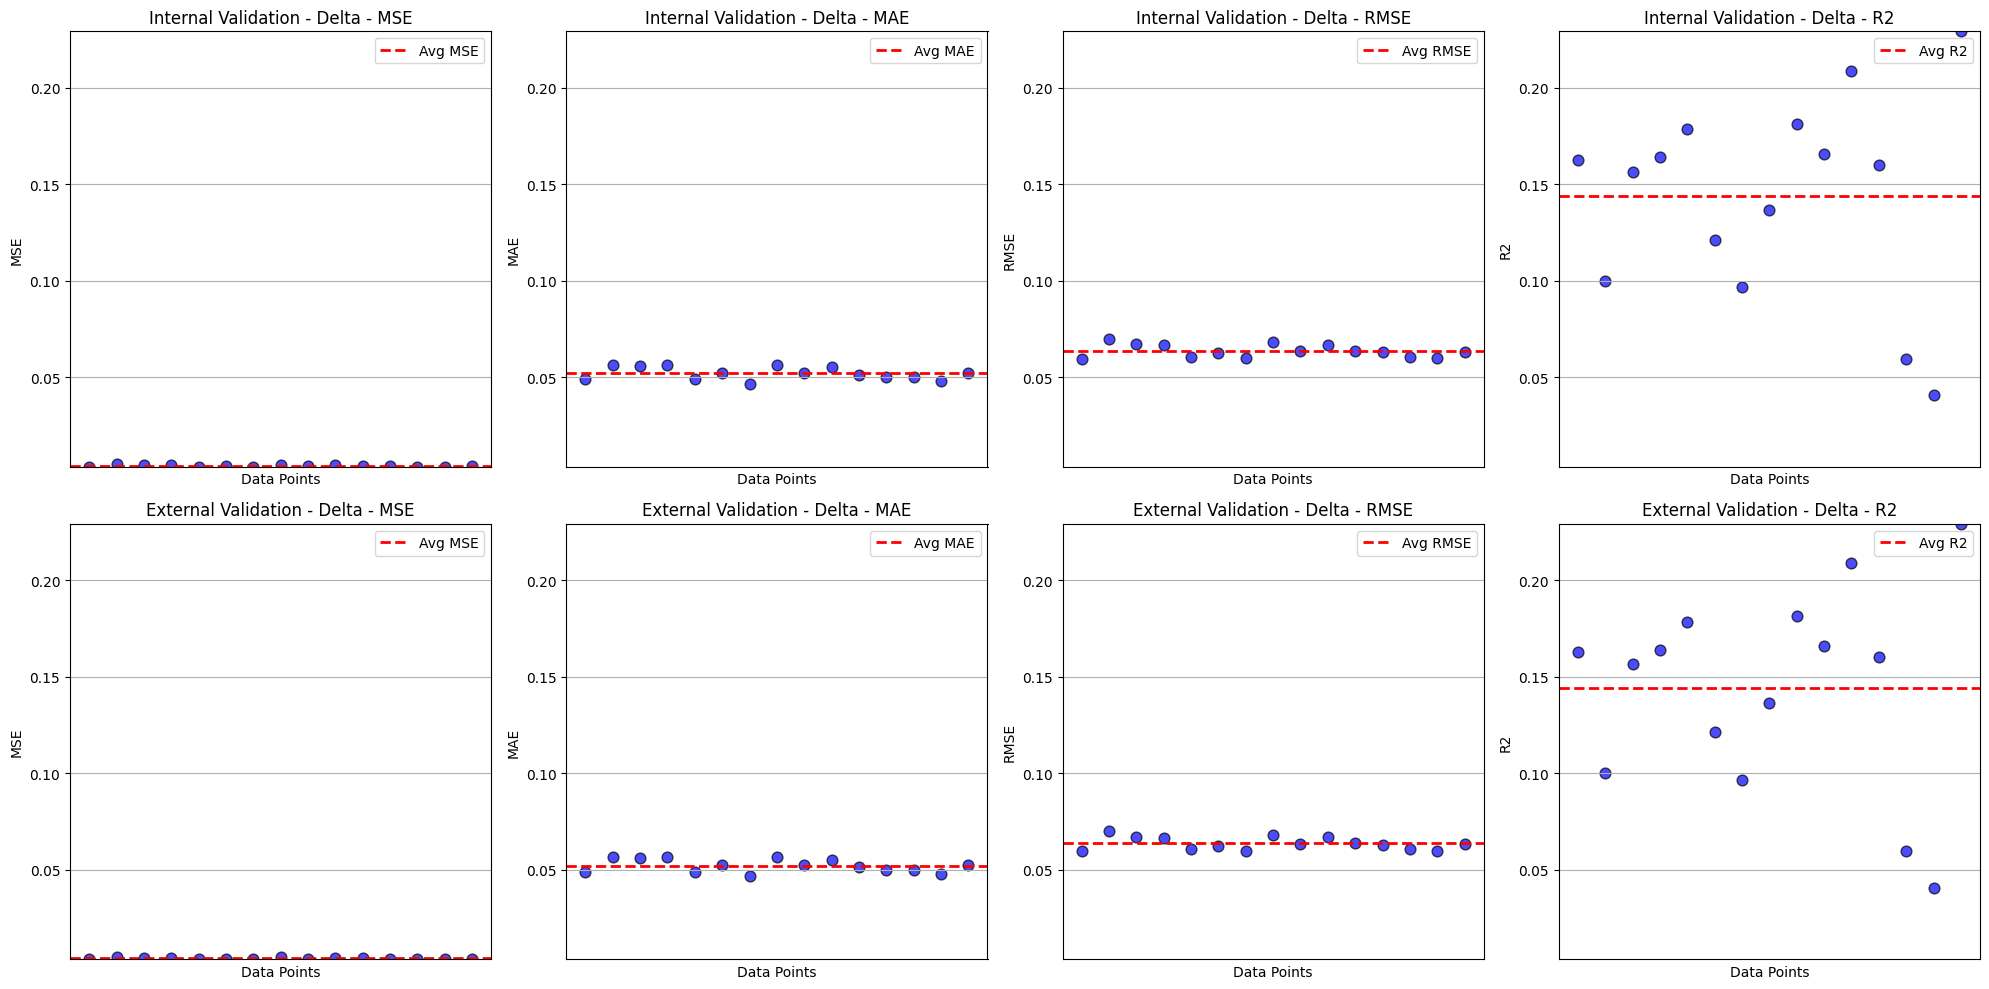

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from mpl_toolkits.mplot3d import Axes3D

def load_cheby_data(coord_path='coords.npy', power_path='band_powers.npy', band='Delta'):
    coords = np.load(coord_path)
    band_powers = np.load(power_path, allow_pickle=True).item()
    print(f"Available bands: {list(band_powers.keys())}")
    values = np.array(band_powers[band])
    return coords, values

def cheby_feature_transform(coords, degree=4):
    scaler = StandardScaler()
    coords_scaled = scaler.fit_transform(coords)
    poly = PolynomialFeatures(degree=degree)
    features = poly.fit_transform(coords_scaled)
    return features, scaler, poly

def cheby_interpolate(coords, values, degree=4):
    features, scaler, poly = cheby_feature_transform(coords, degree)
    model = RidgeCV(alphas=np.logspace(-3, 3, 20), cv=5)
    model.fit(features, values)
    return model, scaler, poly

def cheby_predict(model, scaler, poly, new_coords):
    new_scaled = scaler.transform(new_coords)
    new_features = poly.transform(new_scaled)
    predictions = model.predict(new_features)
    return predictions

def cheby_cross_validate(coords, values, degree=4, k=10):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    all_metrics = {"MSE": [], "MAE": [], "RMSE": [], "R2": []}

    for train_idx, test_idx in kf.split(coords):
        train_coords, test_coords = coords[train_idx], coords[test_idx]
        train_values, test_values = values[train_idx], values[test_idx]

        model, scaler, poly = cheby_interpolate(train_coords, train_values, degree)
        preds = cheby_predict(model, scaler, poly, test_coords)

        metrics = evaluate_cheby_metrics(test_values, preds)
        for key in all_metrics:
            all_metrics[key].append(metrics[key])

    return all_metrics

def evaluate_cheby_metrics(true, pred):
    mask = ~np.isnan(pred)
    mse = mean_squared_error(true[mask], pred[mask])
    mae = mean_absolute_error(true[mask], pred[mask])
    rmse = np.sqrt(mse)
    r2 = r2_score(true[mask], pred[mask])
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

def visualize_cheby_3d(original_coords, original_values, interp_coords, interp_values):
    fig = plt.figure(figsize=(12, 5))

    vmin = min(original_values.min(), interp_values.min())
    vmax = max(original_values.max(), interp_values.max())

    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(original_coords[:, 0], original_coords[:, 1], original_coords[:, 2], c=original_values, cmap='jet', vmin=vmin, vmax=vmax)
    ax1.set_title("Original SEEG Data")

    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(interp_coords[:, 0], interp_coords[:, 1], interp_coords[:, 2], c=interp_values, cmap='jet', vmin=vmin, vmax=vmax)
    ax2.set_title("Interpolated SEEG Data")

    for ax in [ax1, ax2]:
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

    plt.tight_layout()
    plt.show()

def print_cheby_metrics(metrics):
    print("=== Average Cross-Validation Metrics ===")
    for key, values in metrics.items():
        print(f"{key}: {np.mean(values):.4f}")

def generate_cheby_grid(coords, num_points=None):
    if num_points is None:
        num_points = len(coords)
    grid_x = np.random.uniform(coords[:, 0].min(), coords[:, 0].max(), num_points)
    grid_y = np.random.uniform(coords[:, 1].min(), coords[:, 1].max(), num_points)
    grid_z = np.random.uniform(coords[:, 2].min(), coords[:, 2].max(), num_points)
    return np.column_stack([grid_x, grid_y, grid_z])
def plot_cheby_scatter(metric_values, metric_name, validation_type, band, ax, avg_value, min_val, max_val):
    ax.set_ylim(min_val, max_val)
    ax.scatter(np.arange(len(metric_values)), metric_values, alpha=0.7, color='b', edgecolors='black', s=60)
    ax.set_xticks([])
    ax.set_xlabel("Data Points")
    ax.set_ylabel(metric_name)
    ax.set_title(f"{validation_type} Validation - {band} - {metric_name}")
    ax.grid(True)
    ax.axhline(y=avg_value, color='red', linestyle='--', linewidth=2, label=f'Avg {metric_name}')
    ax.legend()

def plot_cheby_all_metrics(internal_metrics, external_metrics, band):
    all_values = list(internal_metrics.values()) + list(external_metrics.values())
    all_metrics_values = np.concatenate([np.array(values) for values in all_values])
    min_val, max_val = np.min(all_metrics_values), np.max(all_metrics_values)

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    for i, (metric_name, values) in enumerate(internal_metrics.items()):
        avg_value = np.mean(values)
        ax = axes[0, i]
        plot_cheby_scatter(values, metric_name, "Internal", band, ax, avg_value, min_val, max_val)

    for i, (metric_name, values) in enumerate(external_metrics.items()):
        avg_value = np.mean(values)
        ax = axes[1, i]
        plot_cheby_scatter(values, metric_name, "External", band, ax, avg_value, min_val, max_val)

    plt.tight_layout()
    plt.show()

def main():
    coords, values = load_cheby_data()
    degree = 4

    # intepolation
    model, scaler, poly = cheby_interpolate(coords, values, degree=degree)

    # validatiion
    metrics = cheby_cross_validate(coords, values, degree=degree, k=10)
    print_cheby_metrics(metrics)

    # intepolation network and visualization
    grid_coords = generate_cheby_grid(coords)
    interp_values = cheby_predict(model, scaler, poly, grid_coords)
    visualize_cheby_3d(coords, values, grid_coords, interp_values)
    internal_metrics = cheby_cross_validate(coords, values, degree=degree, k=15)
    external_metrics = cheby_cross_validate(coords, values, degree=degree, k=15)

    plot_cheby_all_metrics(internal_metrics, external_metrics, band='Delta')


if __name__ == "__main__":
    main()
